# Notebook 16 (V4_3) — Notebook 15 Calibration with a Realized Switch at Period 16

This notebook applies the AHP-pattern calibration selected in Notebook 15 to a realized history in which the economy is in regime $u$ for periods $1,\ldots,15$ and in the absorbing regime $b$ from period 16 onward. It reproduces Section 2 of Notebook 05 at this calibration and exports numerical validation tables.

## 1. Review of the Notebook 05 switch construction

The deterministic construction in Notebook 05 is the right model simulation for a **realized, unannounced stochastic switch**. With $\tau=16$, periods 1–15 use the solved $u$ policy. Period 16 inherits the knowledge stocks produced by the period-15 $u$ allocation, selects the absorbing equilibrium at that inherited state, and all later knowledge stocks are advanced using the realized $b$ allocations. One must therefore re-solve the absorbing equilibrium along the realized post-switch state path; simply splicing later entries of `bgp_seq` onto the $u$ path would be incorrect because those entries lie on the counterfactual all-$u$ knowledge path.

Two qualifications matter. First, agents before period 16 continue to price the hazard $1-\pi$ every period; period 16 is not a deterministic burst date anticipated in advance. Second, Notebook 05's separate Monte Carlo cell draws before recording the initially stated $u$ period and can consequently report $\tau=1$; that off-by-one issue does not affect its deterministic Section 2 construction or this notebook.

For the Notebook 15 calibration, the companion implementation also validates every realized absorbing solve and carries the preceding state's effective exponent as the next common-growth solver seed. This is a numerical-continuation safeguard: it preserves the same state-specific common-growth condition while preventing a failed solve from silently introducing `NaN` values.

## 2. Plot the V4_3 Transition: Notebook 15 Calibration at $\tau=16$

The first four series match Section 2 of Notebook 05: the U.S. per-variety price-dividend ratio, U.S. labor allocation, U.S. output, and relative country size. Two new panels show the per-variety U.S. stock price $q_{US,t}$ and U.S. net foreign assets as a fraction of current U.S. output, $NFA_{US,t}/Y_{US,t}$. Dotted lines show the no-switch all-$u$ counterfactual for the price-dividend ratio, stock price, and NFA. The absorbing $b$ branch is fundamental by equilibrium selection; a fall in $q/d$ is not itself the definition of a burst. At this calibration the equity price $q$ falls at the switch, but the dividend falls more, so $q/d$ rises and then stabilizes.

  Activating 

Notebook 15 selected calibration: pathwise_hi_exp_pi075

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`



Switch convention: u for t < 16, b for t >= 16
Output directory: /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_calibration_switch_at_16
Cold all-u solve: converged=true, max u residual=1.147e-09, max BGP residual=9.757e-10
Reference calibrated nu_b: 1.660652987 (Notebook 15 export 1.660652987)

Switch event at t=16
  q_US/d_US: t15 31.269505 -> t16 b 36.368309 (+16.306%); t16 all-u 31.411825
  q_US:      t15 1.324484 -> t16 b 1.062493 (-19.781%)
  d_US:      t15 0.042357 -> t16 b 0.029215 (-31.027%)
  Y_US:      t15 3.507377 -> t16 b 2.016691 (-42.501%)
  realized nu_b_eff range: [0.788354623, 0.788354645], span 2.198e-08
  maximum b residual: 9.728e-10; common-growth log gap: 9.615e-10
  literal Notebook-05 helper first non-finite period: 26
  checked continuation is finite through period 30

Interpretation: period 16 is a realized, unannounced switch under hazard pi,
not a date-16 event anticip

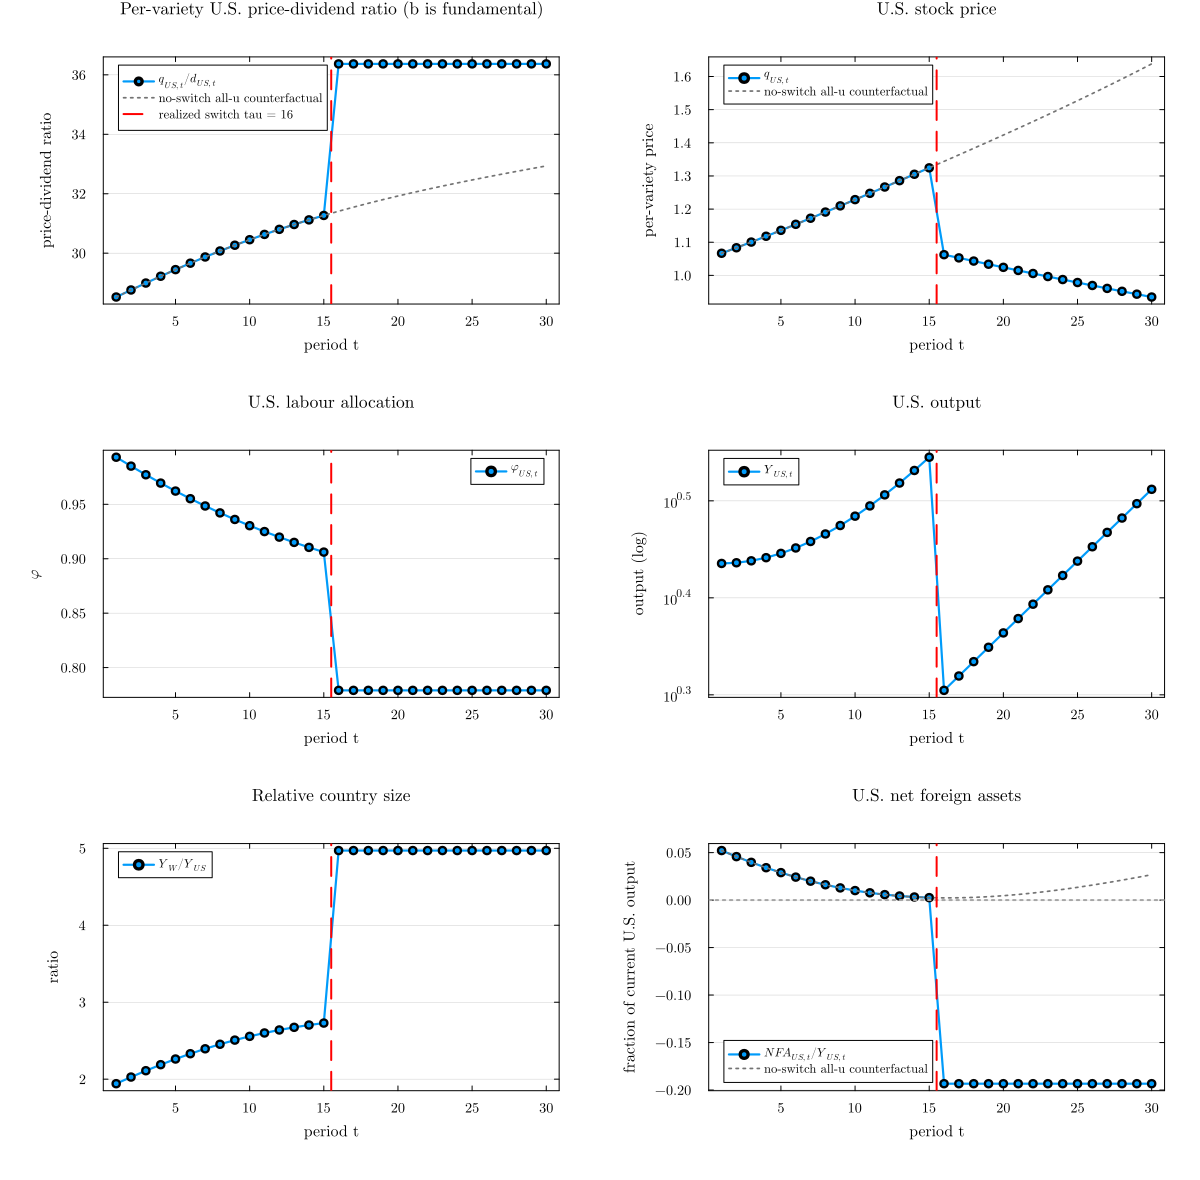

In [1]:
notebook_dir = if isfile(joinpath(pwd(), "16_v9_ahp_calibration_switch_at_16.jl"))
    pwd()
elseif isfile(joinpath(pwd(), "Two_country_production", "16_v9_ahp_calibration_switch_at_16.jl"))
    joinpath(pwd(), "Two_country_production")
else
    error("Run this notebook from the repository root or Two_country_production directory.")
end
include(joinpath(notebook_dir, "16_v9_ahp_calibration_switch_at_16.jl"))

## 3. Reading the switch diagnostics

`switch_event_summary.csv` separates the adjacent-date change from period 15 to period 16 from the economically cleaner burst comparison between realized $b_{16}$ and counterfactual $u_{16}$ at the same inherited state. `simulation_validation.csv` checks regime timing, state inheritance, post-switch knowledge recursions, the NFA portfolio identity, absorbing-equilibrium convergence, pathwise common growth, and the ordering $\nu_b^{eff}<\nu_u$. `switch_path_t16.csv` contains the realized and no-switch stock-price and NFA series needed for further plots. Reproduction within this repository uses the tracked Notebook 15 `candidate_summary.csv`, the shared model module, and the companion `16_v9_ahp_calibration_switch_at_16.jl`.